<a href="https://colab.research.google.com/github/Amber-0117/Test0207/blob/main/MLP_tsmc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#MLP predict closing stock price of a corporation (tsmc)

In [ ]:
#import libraries
import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from keras.utils import plot_model
plt.style.use('fivethirtyeight')

In [ ]:
#get the stock quote
import yfinance as yf
df = yf.download('TSM',start='2020-01-01', end='2026-07-01')
#show the data
df

/tmp/ipykernel_3578/234115523.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('TSM',start='2020-01-01', end='2026-07-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSM,TSM,TSM,TSM,TSM
Date,,,,,
2020-01-02,53.503265,53.574554,53.111167,53.111167,8432600
2020-01-03,51.738846,52.558681,51.721023,52.549771,10546400
2020-01-06,51.141777,51.409114,50.910086,51.328913,8897200
2020-01-07,51.970535,52.220050,50.562556,51.195256,7444300
2020-01-08,52.353714,52.558673,51.783393,51.854682,5381500
...,...,...,...,...,...
2026-06-24,440.829987,443.859985,432.579987,433.980011,9991200
2026-06-25,434.989990,452.899994,432.440002,452.899994,14769500


In [ ]:
#get the number of rows and columns in the data set
df.shape

(1631, 5)

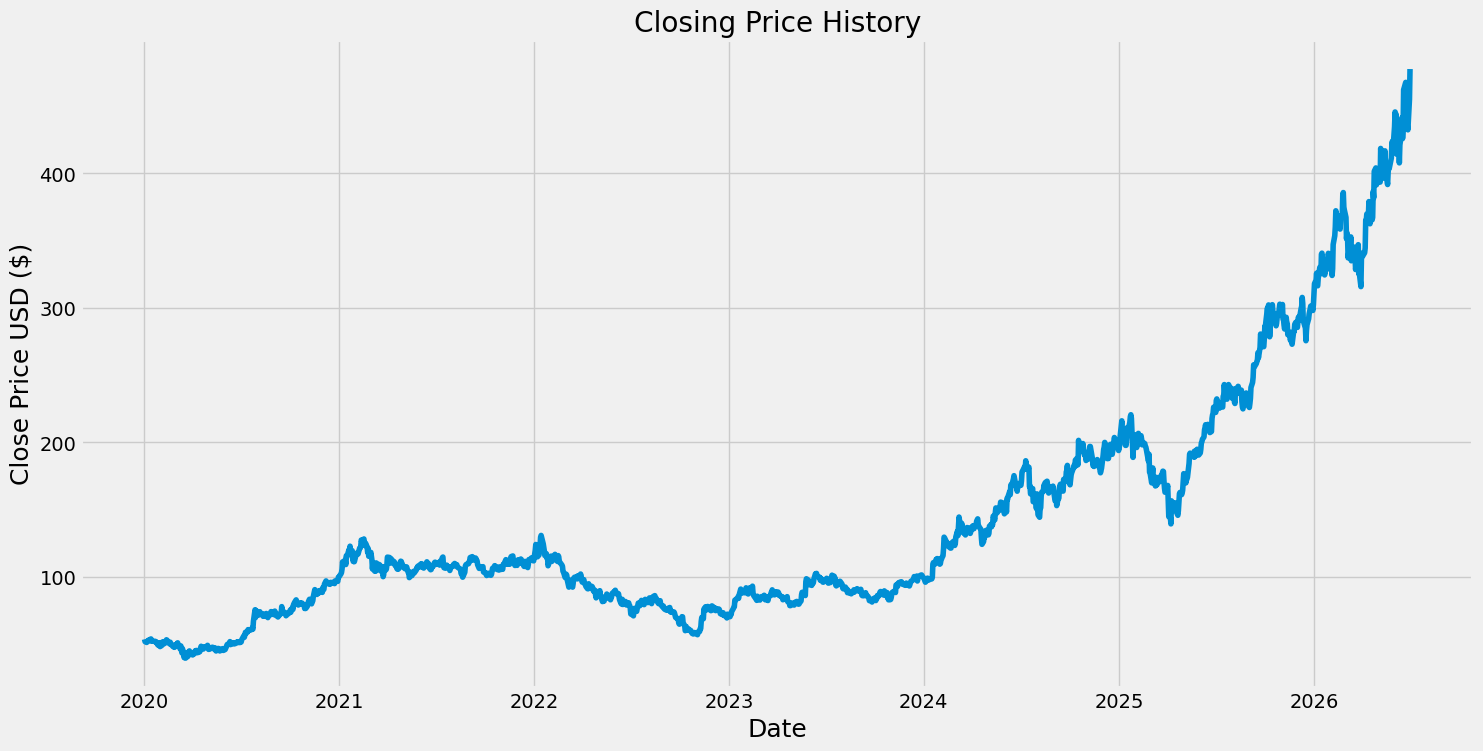

In [ ]:
#visualize the closing price history
plt.figure(figsize=(16,8))
plt.title('Closing Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [ ]:
#create a new dataframe with only the "Close column"
data = df[['Close']]
#convert the dataframe to a numpy array
dataset = data.values
#get the number of rows to train the model on (80%)
training_data_len = math.ceil(len(dataset)*.8)

training_data_len

1305

In [ ]:
#Scale the data
scaler =  MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data


array([[0.03200419],
       [0.02797664],
       [0.02661374],
       ...,
       [0.89677858],
       [0.94870886],
       [1.        ]])

In [ ]:
#create the training dataset
#create the scaled training dataset
train_data = scaled_data[0:training_data_len, :]
#split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

[array([0.03200419, 0.02797664, 0.02661374, 0.02850551, 0.02938017,
       0.03035656, 0.02960392, 0.03204488, 0.03257376, 0.02864789,
       0.02938017, 0.02903439, 0.02834277, 0.02856651, 0.02679684,
       0.02730536, 0.02228106, 0.02600351, 0.02620692, 0.02337949,
       0.01959601, 0.02128433, 0.02687821, 0.02769185, 0.02789525,
       0.02419316, 0.02586112, 0.02919712, 0.0311702 , 0.03055998,
       0.02824107, 0.02415247, 0.0271223 , 0.02476271, 0.02295232,
       0.01996216, 0.01943329, 0.02181321, 0.0182738 , 0.0193926 ,
       0.02374564, 0.02150812, 0.02598317, 0.0232371 , 0.02189456,
       0.01530399, 0.02075547, 0.01613799, 0.00891682, 0.01611763,
       0.00120745, 0.00861169, 0.00012938, 0.        , 0.00131421,
       0.00281319, 0.0102261 , 0.01049303, 0.0122795 , 0.00620137])]
[np.float64(0.00807001955391276)]

[array([0.03200419, 0.02797664, 0.02661374, 0.02850551, 0.02938017,
       0.03035656, 0.02960392, 0.03204488, 0.03257376, 0.02864789,
       0.02938017, 0.02

In [ ]:
#convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

#reshape the data (MLP expects 2 dimentionals)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1]))
x_train.shape


(1245, 60)

In [ ]:
#build MLP model
model = Sequential()
model.add(Dense(150, activation='relu', input_dim = 60))
model.add(Dense(150, activation='relu'))
model.add(Dense(1))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 150)            │         9,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,951 (124.81 KB)

 Trainable params: 31,951 (124.81 KB)

 Non-trainable params: 0 (0.00 B)

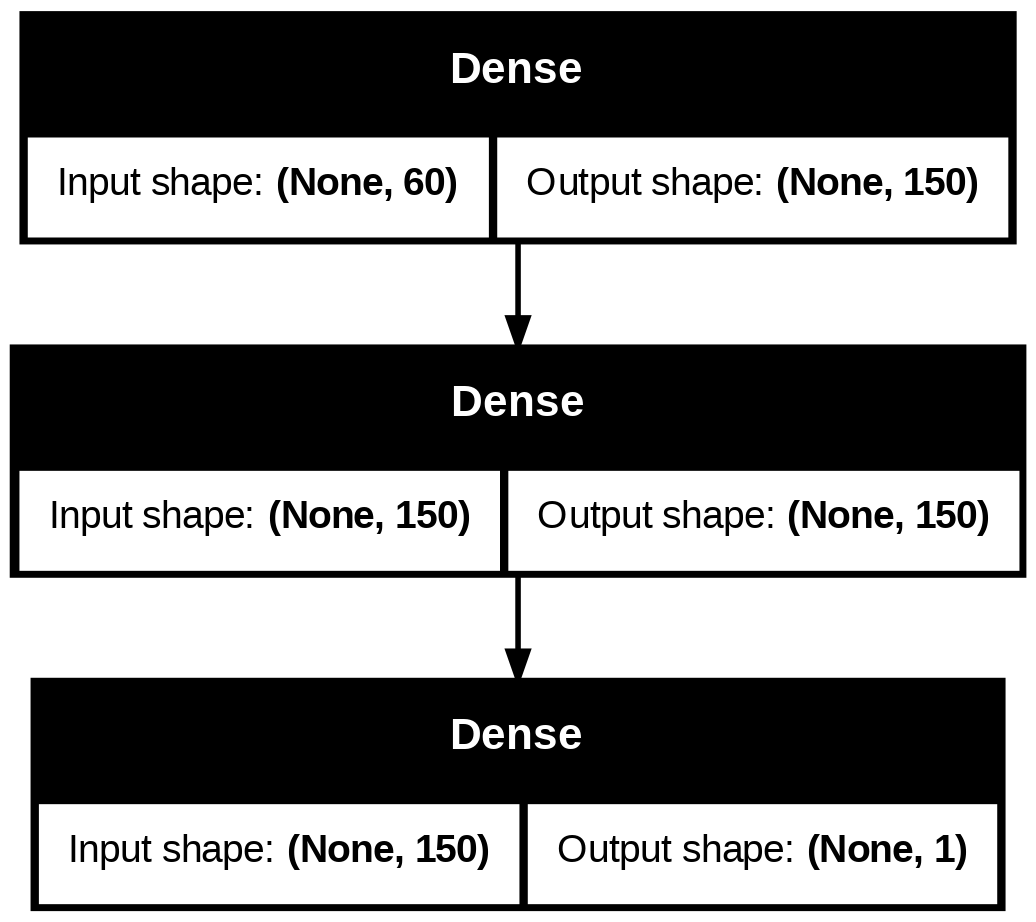

In [ ]:
plot_model(model, to_file='modeltsmc.png', show_shapes=True)

In [ ]:
#compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
#train the model
history = model.fit(x_train, y_train, batch_size=1, epochs=20)

Epoch 1/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7.3440e-04
Epoch 2/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.4580e-04
Epoch 3/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.6274e-04
Epoch 4/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.0230e-04
Epoch 5/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.1231e-04
Epoch 6/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.0138e-04
Epoch 7/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.7279e-04
Epoch 8/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.8007e-04
Epoch 9/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.9137e-04
Epoch 10/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.4948e-04
Epoch 11/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.4416e-04
Epoch 12/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.5002e-04
Epoch 13/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.3214e-04
Epoch 14/20
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 3s 3

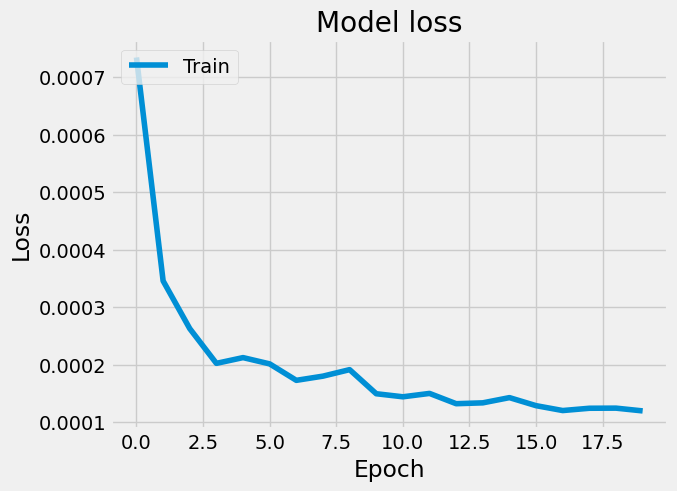

In [ ]:
#show model loss
plt.plot(history.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
#create the testing data set
#create a new array containing scaled values from index
test_data = scaled_data[training_data_len - 60: , : ]
#create the datasets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range (60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

In [ ]:
#convert the data to a numpy array
x_test = np.array(x_test)

In [ ]:
#reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1]))

In [ ]:
#get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [ ]:
#get the root mean squared error (RMSE) (lower values better fit)
rmse = np.sqrt( np.mean( predictions - y_test)**2)
print(rmse)

0.5924604919059145


In [ ]:
#get the mean absolute error (average of the forecast error values - all of em forced to be positive)
mae = mean_absolute_error(y_test, predictions)
print(mae)

6.784783205371693


In [ ]:
#define MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
#get MAPE
mape = mean_absolute_percentage_error(y_test, predictions)
print(mape)

2.3938707907292294


/tmp/ipykernel_3578/2676792390.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


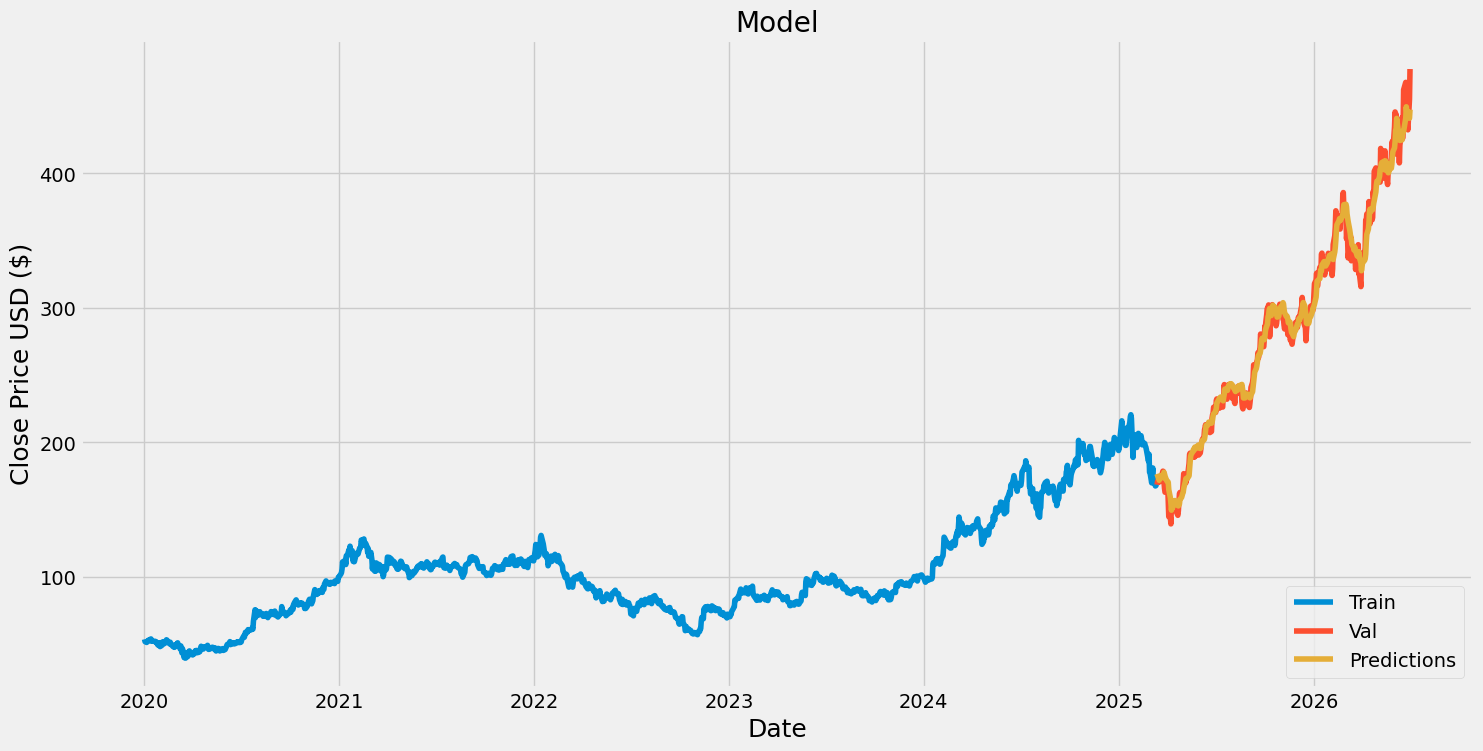

In [ ]:
#plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
#visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

/tmp/ipykernel_3578/2014408584.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


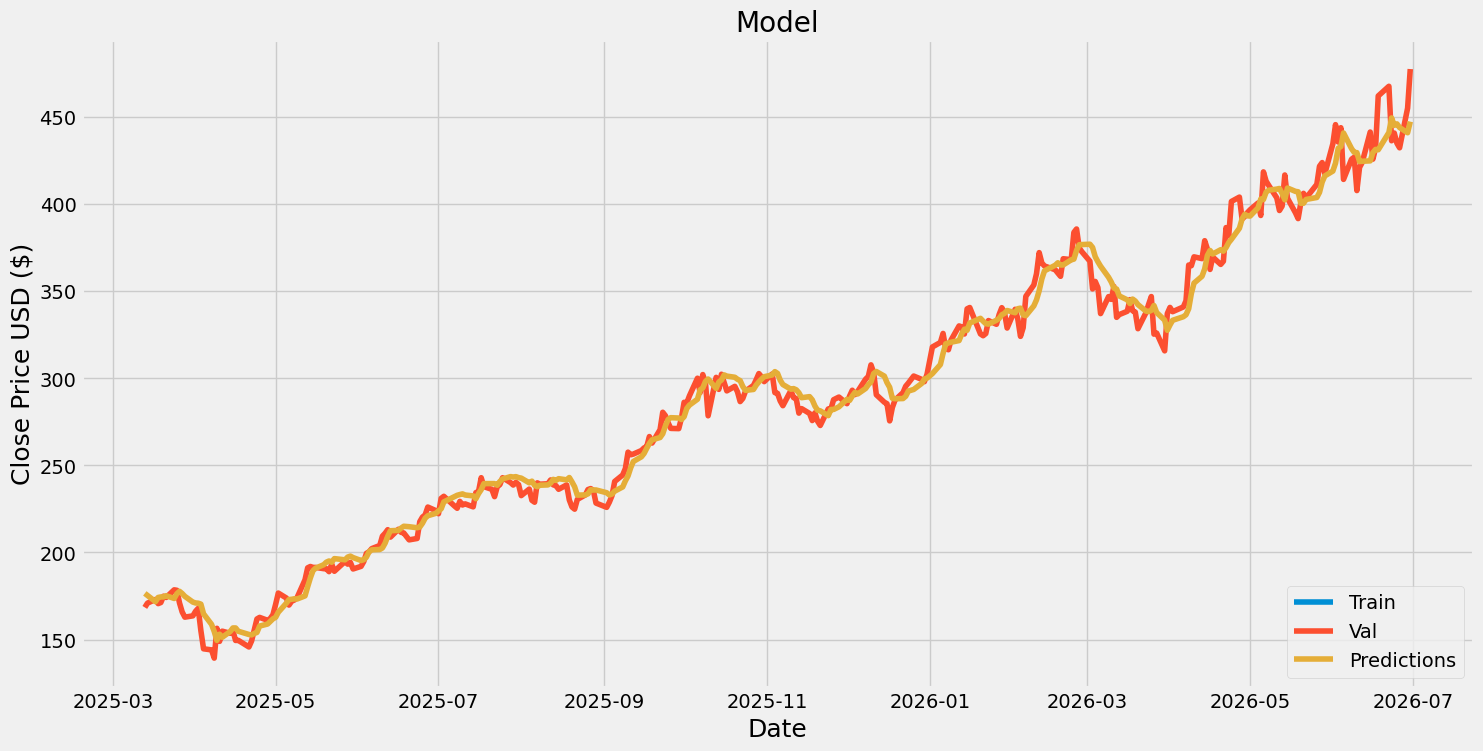

In [ ]:
#plot zoomed in
train = data[2000:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
#visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [ ]:
#show the valid and predicted prices
valid

Price,Close,Predictions
Ticker,TSM,
Date,,
2025-03-13,168.438492,176.489304
2025-03-14,170.892578,175.301865
2025-03-17,173.003113,171.728043
2025-03-18,170.612381,174.157318
2025-03-19,171.233215,174.452515
...,...,...
2026-06-24,440.829987,445.247040
2026-06-25,434.989990,446.080078


In [ ]:
#Get the quote
tsmc_quote = yf.download('TSM',start='2020-01-01', end='2026-08-04')
#Create a new dataframe
new_df = tsmc_quote[['Close']]
#Get teh last 60 day closing price
last_60_days = new_df[-60:].values
#Scale the data to be values between 0 and 1
last_60_days_scaled = scaler.transform(last_60_days)
#Create an empty list
X_test = []
#Append teh past 60 days
X_test.append(last_60_days_scaled)
#Convert the X_test data set to a numpy array
X_test = np.array(X_test)
#Reshape the data
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1]))
#Get the predicted scaled price
pred_price = model.predict(X_test)
#undo the scaling
pred_price = scaler.inverse_transform(pred_price)
print(pred_price)


/tmp/ipykernel_3578/3685594353.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tsmc_quote = yf.download('TSM',start='2020-01-01', end='2026-08-04')
[*********************100%***********************]  1 of 1 completed


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[401.5418]]


In [ ]:
tsmc_quote2 = yf.download('TSM', start='2026-08-03', end='2026-08-04')
print(tsmc_quote2['Close'])

/tmp/ipykernel_3578/2185208681.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tsmc_quote2 = yf.download('TSM', start='2026-08-03', end='2026-08-04')
[*********************100%***********************]  1 of 1 completed

Ticker             TSM
Date                  
2026-08-03  406.109985


In [ ]:
pip install yfinance